In [19]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

In [20]:
# Load the dataset
DATASET = "COMP 1886 - Coursework Dataset.xlsx"

mp_raw  = pd.read_excel(DATASET, sheet_name="Mean Pay (industry)",  header=None)
emp_raw = pd.read_excel(DATASET, sheet_name="Employees (Industry)", header=None)

# Define constants for header and data start rows
MP_HEADER_ROW  = 5
MP_DATA_START  = 6
EMP_HEADER_ROW = 5
EMP_DATA_START = 6

# Process Mean Pay sheet
print("Dataset loaded successfully.")
print(f"  Mean Pay sheet  : {mp_raw.shape[0]-MP_DATA_START} monthly observations, {mp_raw.shape[1]} columns")
print(f"  Employees sheet : {emp_raw.shape[0]-EMP_DATA_START} monthly observations, {emp_raw.shape[1]} columns")
print(f"  Mean Pay   date range : {mp_raw.iloc[MP_DATA_START,0]}  to  {mp_raw.iloc[-1,0]}")
print(f"  Employees  date range : {emp_raw.iloc[EMP_DATA_START,0]}  to  {emp_raw.iloc[-1,0]}")

Dataset loaded successfully.
  Mean Pay sheet  : 132 monthly observations, 24 columns
  Employees sheet : 133 monthly observations, 22 columns
  Mean Pay   date range : July 2014  to  June 2025
  Employees  date range : July 2014  to  July 2025


---
# Task 2: Exploratory Data Analysis (EDA)

Two EDAs are performed on the PAYE RTI dataset. Each begins with a clearly stated hypothesis, 
followed by attribute selection, visualisation, and a written interpretation connected to the 
PAYE policy context.

## EDA #1: Sectoral Wage Inequality Analysis

**Hypothesis:** Finance & Insurance sector employees earn significantly higher mean monthly wages 
than Accommodation & Food Service employees, and this absolute gap widens over time despite 
comparable percentage growth rates — reflecting structural, skill-based wage stratification 
in UK PAYE RTI data (July 2014 – June 2025).

**Attributes Selected:**
- **Mean Pay col 13 – Finance & Insurance wages:** Highest-wage, high-skill sector in the dataset  
- **Mean Pay col 11 – Accommodation & Food Service wages:** Lowest-wage, labour-intensive sector  
- **Date (col 0):** 132-month temporal dimension

**Justification:** These two sectors represent the extremes of the UK wage distribution within 
PAYE RTI data, making them ideal candidates for studying structural wage inequality over time.

In [21]:
# EDA #1: Sectoral Wage Inequality
print("=" * 70)
print("EDA #1: SECTORAL WAGE INEQUALITY — FINANCE vs ACCOMMODATION")
print("=" * 70)

# Extract wages using correct raw column indices (verified against header row 5)
finance_wages      = pd.to_numeric(mp_raw.iloc[MP_DATA_START:, 13], errors='coerce')
accommodation_wages = pd.to_numeric(mp_raw.iloc[MP_DATA_START:, 11], errors='coerce')
dates_mp           = mp_raw.iloc[MP_DATA_START:, 0].reset_index(drop=True)

# Drop NaN and align by resetting index
finance_wages       = finance_wages.reset_index(drop=True)
accommodation_wages = accommodation_wages.reset_index(drop=True)

# Confirming correct columns by checking header row
print(f"\nConfirmed columns:")
print(f"  Col 13 = '{mp_raw.iloc[5, 13]}'")
print(f"  Col 11 = '{mp_raw.iloc[5, 11]}'")

# Display summary statistics in a formatted table
print(f"\n{'Statistic':<25} {'Finance & Insurance':>22} {'Accommodation':>18}")
print("-" * 70)
for stat, fin_val, acc_val in [
    ("Count",     f"{finance_wages.count()}",          f"{accommodation_wages.count()}"),
    ("Mean (£)",  f"£{finance_wages.mean():,.0f}",     f"£{accommodation_wages.mean():,.0f}"),
    ("Median (£)",f"£{finance_wages.median():,.0f}",   f"£{accommodation_wages.median():,.0f}"),
    ("Min (£)",   f"£{finance_wages.min():,.0f}",      f"£{accommodation_wages.min():,.0f}"),
    ("Max (£)",   f"£{finance_wages.max():,.0f}",      f"£{accommodation_wages.max():,.0f}"),
    ("Std Dev",   f"£{finance_wages.std():,.0f}",      f"£{accommodation_wages.std():,.0f}"),
]:
    print(f"  {stat:<23} {fin_val:>22} {acc_val:>18}")

# Calculate and display wage ratio and growth rates
wage_ratio = finance_wages.mean() / accommodation_wages.mean()
fin_growth = (finance_wages.dropna().iloc[-1] / finance_wages.dropna().iloc[0] - 1) * 100
acc_growth = (accommodation_wages.dropna().iloc[-1] / accommodation_wages.dropna().iloc[0] - 1) * 100
print(f"\n  Wage ratio (Finance / Accommodation): {wage_ratio:.2f}x")
print(f"  Finance growth  (Jul 2014 – Jun 2025): {fin_growth:.1f}%")
print(f"  Accommodation growth (Jul 2014 – Jun 2025): {acc_growth:.1f}%")

EDA #1: SECTORAL WAGE INEQUALITY — FINANCE vs ACCOMMODATION

Confirmed columns:
  Col 13 = 'Finance and insurance'
  Col 11 = 'Accommodation and food service activities'

Statistic                    Finance & Insurance      Accommodation
----------------------------------------------------------------------
  Count                                      132                129
  Mean (£)                                £6,206             £1,327
  Median (£)                              £5,779             £1,270
  Min (£)                                 £4,019             £1,086
  Max (£)                                £11,981             £1,755
  Std Dev                                 £1,778               £180

  Wage ratio (Finance / Accommodation): 4.68x
  Finance growth  (Jul 2014 – Jun 2025): 66.8%
  Accommodation growth (Jul 2014 – Jun 2025): 59.4%


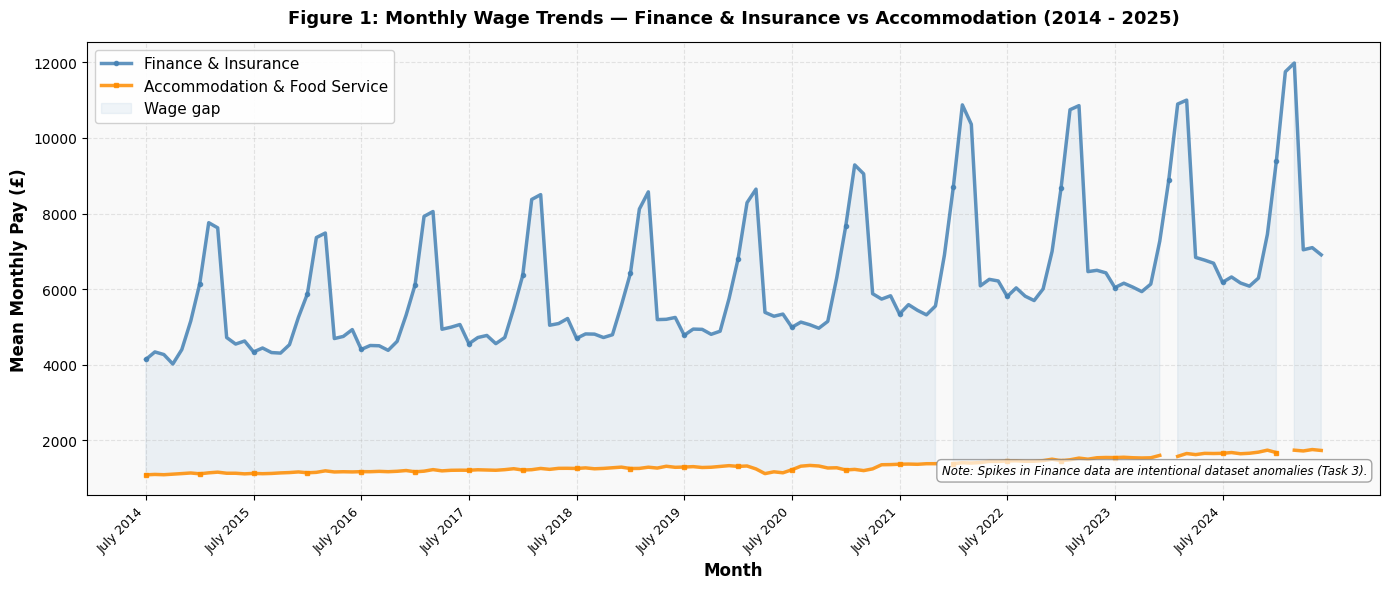

In [22]:
# EDA #1 Plot 1: Time-series wage comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Plot both sectors with distinct styles
ax.plot(range(len(finance_wages)), finance_wages,
        label='Finance & Insurance', color='steelblue', linewidth=2.5,
        marker='o', markersize=3, markevery=6, alpha=0.85, zorder=3)
# Plot Accommodation with a contrasting style
ax.plot(range(len(accommodation_wages)), accommodation_wages,
        label='Accommodation & Food Service', color='darkorange', linewidth=2.5,
        marker='s', markersize=3, markevery=6, alpha=0.85, zorder=3)

# Shade the gap between sectors
ax.fill_between(range(len(finance_wages)),
                accommodation_wages, finance_wages,
                alpha=0.08, color='steelblue', label='Wage gap')

# Customize x-axis with monthly ticks and formatted labels
tick_positions = range(0, len(dates_mp), 12)
tick_labels    = [dates_mp.iloc[i] for i in tick_positions] 
ax.set_xticks(tick_positions) # Set ticks at yearly intervals
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9) # Format labels as 'YYYY-MM'
ax.set_xlabel('Month', fontsize=12, fontweight='bold') # Set x-axis label
ax.set_ylabel('Mean Monthly Pay (£)', fontsize=12, fontweight='bold') # Set y-axis label
ax.set_title('Figure 1: Monthly Wage Trends — Finance & Insurance vs Accommodation (2014 - 2025)',
             fontsize=13, fontweight='bold', pad=14) # Set title with padding
ax.legend(fontsize=11, loc='upper left', framealpha=0.9) # Add legend with slight transparency
ax.grid(True, alpha=0.3, linestyle='--') # Add grid for better readability
ax.set_facecolor('#f9f9f9') # Set a light background color
ax.text(0.99, 0.04,
        'Note: Spikes in Finance data are intentional dataset anomalies (Task 3).',
        transform=ax.transAxes, fontsize=8.5, ha='right', va='bottom', style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='grey')) # Add a note about anomalies
plt.tight_layout() 
plt.savefig('eda1_fig1_wage_timeseries.png', dpi=300, bbox_inches='tight') # Save the plot as a high-resolution PNG file
plt.show() # Display the plot

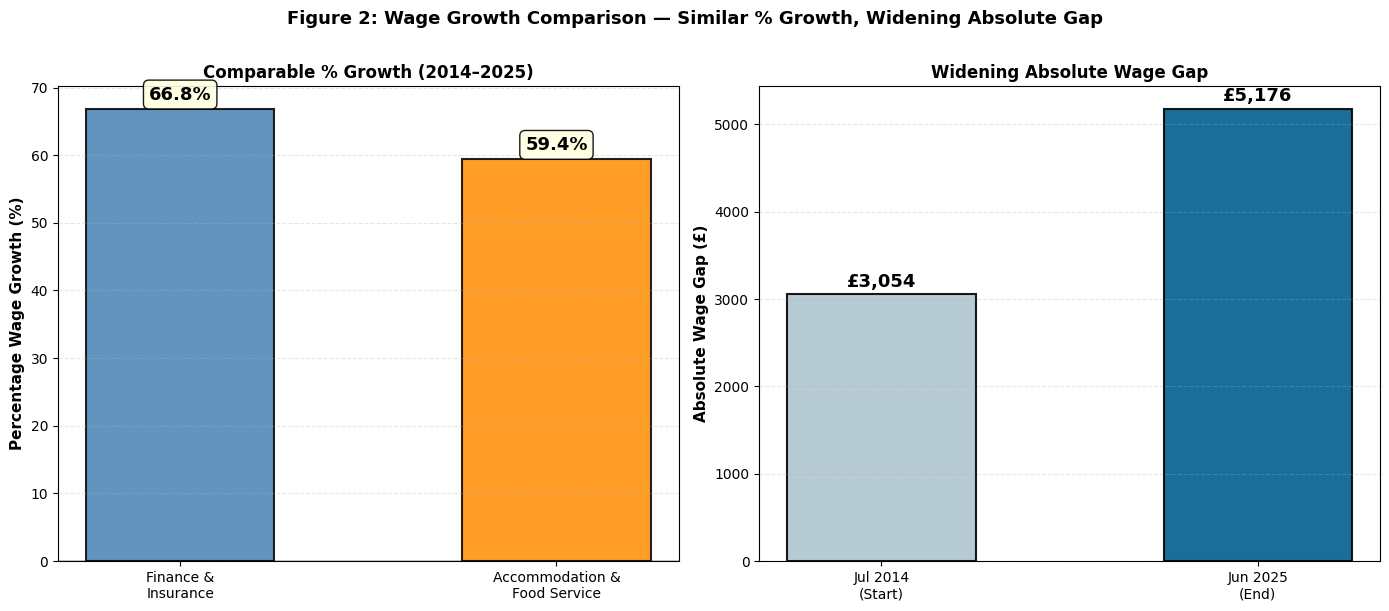


Absolute gap grew from £3,054 to £5,176


In [23]:
# EDA #1 Plot 2: Absolute gap growth bar chart
absolute_gap_start = finance_wages.dropna().iloc[0] - accommodation_wages.dropna().iloc[0]
absolute_gap_end   = finance_wages.dropna().iloc[-1] - accommodation_wages.dropna().iloc[-1]

# Create a side-by-side bar chart to compare % growth and absolute gap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: % growth comparison
sectors  = ['Finance &\nInsurance', 'Accommodation &\nFood Service'] # Use multi-line labels for better readability
growths  = [fin_growth, acc_growth] # Calculate percentage growth for both sectors
colors   = ['steelblue', 'darkorange'] # Define colors for the bars
bars = axes[0].bar(sectors, growths, color=colors, width=0.5,
                   edgecolor='black', linewidth=1.5, alpha=0.85) # Create bars for percentage growth
# Annotate bars with growth values
for bar, val in zip(bars, growths):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=13,
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                           alpha=0.9, edgecolor='black'))
axes[0].set_ylabel('Percentage Wage Growth (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Comparable % Growth (2014–2025)', fontsize=12, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[0].set_facecolor('white')

# Right: absolute gap
gap_labels = ['Jul 2014\n(Start)', 'Jun 2025\n(End)']
gap_values = [absolute_gap_start, absolute_gap_end]
bar_colors = ['#aec6cf', '#005f8e'] # Define colors for the bars
bars2 = axes[1].bar(gap_labels, gap_values, color=bar_colors, width=0.5,
                    edgecolor='black', linewidth=1.5, alpha=0.9)
# Annotate bars with absolute gap values
for bar, val in zip(bars2, gap_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'£{val:,.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
# Customize the right plot
axes[1].set_ylabel('Absolute Wage Gap (£)', fontsize=11, fontweight='bold') # Set y-axis label
axes[1].set_title('Widening Absolute Wage Gap', fontsize=12, fontweight='bold') # Set title with padding
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[1].set_facecolor('white')
# Add a main title for the entire figure
fig.suptitle('Figure 2: Wage Growth Comparison — Similar % Growth, Widening Absolute Gap',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda1_fig2_wage_gap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nAbsolute gap grew from £{absolute_gap_start:,.0f} to £{absolute_gap_end:,.0f}")

---
## EDA #2: Employment Volatility Analysis

**Hypothesis:** Accommodation & Food Service exhibits higher employment volatility than 
Health & Social Work across the 2014–2025 period, due to discretionary versus essential 
service demand. The COVID-19 shock (March 2020 – June 2021) is expected to amplify 
Accommodation's volatility while Healthcare remains stable.

**Attributes Selected:**
- **Employees col 9 – Accommodation & Food Service employment:** Discretionary-demand sector  
- **Employees col 17 – Health & Social Work employment:** Essential-demand sector  
- **Date (col 0):** 132-month temporal dimension covering COVID-19 pandemic period

**Justification:** Testing discretionary versus essential demand dynamics reveals how PAYE RTI 
data captures differential sectoral responses to macroeconomic shocks, directly relevant to 
labour market policy design.

In [24]:
# EDA #2: Employment Volatility
print("=" * 70)
print("EDA #2: EMPLOYMENT VOLATILITY — ACCOMMODATION vs HEALTHCARE")
print("=" * 70)

# Extract employment using correct raw column indices
accommodation_emp = pd.to_numeric(emp_raw.iloc[EMP_DATA_START:, 9],  errors='coerce').reset_index(drop=True)
health_emp        = pd.to_numeric(emp_raw.iloc[EMP_DATA_START:, 17], errors='coerce').reset_index(drop=True)
dates_emp         = emp_raw.iloc[EMP_DATA_START:, 0].reset_index(drop=True)

# Confirm column names for employment data
print(f"\nConfirmed columns:")
print(f"  Col  9 = '{emp_raw.iloc[5,  9]}'")
print(f"  Col 17 = '{emp_raw.iloc[5, 17]}'")

# Percentage CV calculation for both sectors
acc_cv    = (accommodation_emp.std() / accommodation_emp.mean()) * 100
health_cv = (health_emp.std()        / health_emp.mean())        * 100

# Print the statistics in a formatted table
print(f"\n{'Statistic':<28} {'Accommodation':>18} {'Health & Social Work':>22}")
print("-" * 70)
for stat, a_val, h_val in [
    ("Mean (employees)",  f"{accommodation_emp.mean():,.0f}", f"{health_emp.mean():,.0f}"),
    ("Std Dev",           f"{accommodation_emp.std():,.0f}",  f"{health_emp.std():,.0f}"),
    ("CV (%)",            f"{acc_cv:.2f}%",                   f"{health_cv:.2f}%"),
    ("Min",               f"{accommodation_emp.min():,.0f}",  f"{health_emp.min():,.0f}"),
    ("Max",               f"{accommodation_emp.max():,.0f}",  f"{health_emp.max():,.0f}"),
]:
    print(f"  {stat:<26} {a_val:>18} {h_val:>22}")

print(f"\n  Finding: Healthcare CV ({health_cv:.2f}%) > Accommodation CV ({acc_cv:.2f}%)")

EDA #2: EMPLOYMENT VOLATILITY — ACCOMMODATION vs HEALTHCARE

Confirmed columns:
  Col  9 = 'Accommodation and food service activities'
  Col 17 = 'Health and social work'

Statistic                         Accommodation   Health & Social Work
----------------------------------------------------------------------
  Mean (employees)                    2,006,529              3,901,818
  Std Dev                               144,158                312,280
  CV (%)                                  7.18%                  8.00%
  Min                                 1,677,264              3,419,006
  Max                                 2,255,164              4,465,093

  Finding: Healthcare CV (8.00%) > Accommodation CV (7.18%)


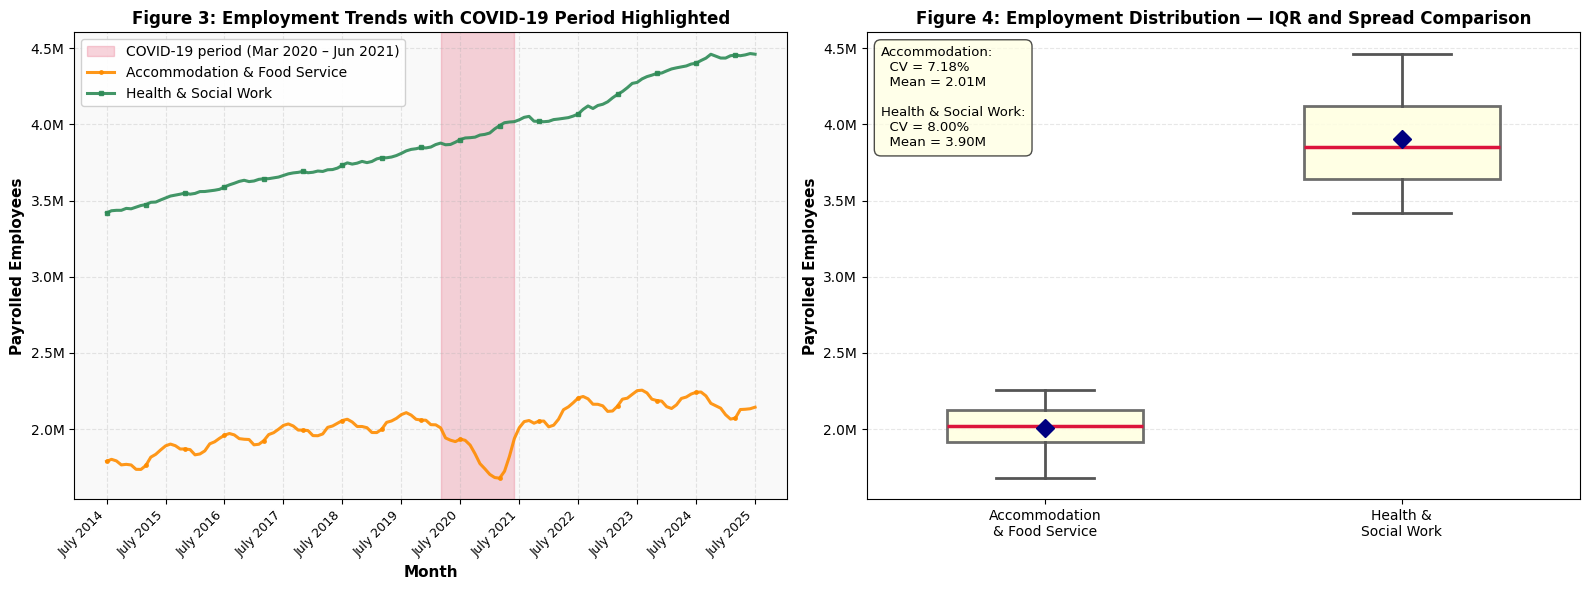

In [25]:
# EDA #2 Plots
# COVID-19 period indices (March 2020 = index 68, June 2021 = index 83)
COVID_START, COVID_END = 68, 83

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Time-series with COVID shading
ax = axes[0]
# Shade COVID-19 period with a semi-transparent red rectangle
ax.axvspan(COVID_START, COVID_END, alpha=0.18, color='crimson',
           label='COVID-19 period (Mar 2020 – Jun 2021)', zorder=1)
# Plot both sectors with distinct styles
ax.plot(range(len(accommodation_emp)), accommodation_emp,
        label='Accommodation & Food Service', color='darkorange',
        linewidth=2.2, marker='o', markersize=2.5, markevery=8, alpha=0.9, zorder=3)
ax.plot(range(len(health_emp)), health_emp,
        label='Health & Social Work', color='seagreen',
        linewidth=2.2, marker='s', markersize=2.5, markevery=8, alpha=0.9, zorder=3)
# Customize x-axis with monthly ticks and formatted labels
tick_pos = range(0, len(dates_emp), 12)
ax.set_xticks(tick_pos)
ax.set_xticklabels([dates_emp.iloc[i] for i in tick_pos], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Month', fontsize=11, fontweight='bold')
ax.set_ylabel('Payrolled Employees', fontsize=11, fontweight='bold')
ax.set_title('Figure 3: Employment Trends with COVID-19 Period Highlighted', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#f9f9f9')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')) # Format y-axis labels as millions

# Plot 2: Box plot
ax2 = axes[1]
# Create a box plot to compare the distribution of employment in both sectors
bp = ax2.boxplot([accommodation_emp.dropna(), health_emp.dropna()],
                 labels=['Accommodation\n& Food Service', 'Health &\nSocial Work'],
                 patch_artist=True, widths=0.55, notch=False, showmeans=True,
                 boxprops=dict(facecolor='lightyellow', alpha=0.85, linewidth=2, edgecolor='#555'),
                 whiskerprops=dict(linewidth=2, color='#555'),
                 capprops=dict(linewidth=2, color='#555'),
                 medianprops=dict(linewidth=2.5, color='crimson'),
                 meanprops=dict(marker='D', markerfacecolor='navy', markeredgecolor='navy', markersize=9))
# Customize the right plot
ax2.set_ylabel('Payrolled Employees', fontsize=11, fontweight='bold')
ax2.set_title('Figure 4: Employment Distribution — IQR and Spread Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.set_facecolor('white')
# Format y-axis labels as millions
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
stats_txt = (f"Accommodation:\n  CV = {acc_cv:.2f}%\n  Mean = {accommodation_emp.mean()/1e6:.2f}M\n\n"
             f"Health & Social Work:\n  CV = {health_cv:.2f}%\n  Mean = {health_emp.mean()/1e6:.2f}M")
# Add a text box with the CV and mean statistics for both sectors
ax2.text(0.02, 0.97, stats_txt, transform=ax2.transAxes, fontsize=9.5, va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7, edgecolor='black'))

plt.tight_layout()
plt.show()

---
# Task 3: Data Pre-Processing

Three preprocessing techniques are applied: missing value imputation to restore dataset 
completeness, IQR-based outlier removal to eliminate Finance sector anomalies, and 
StandardScaler normalisation to equalise feature scales for Task 5 clustering.

## Preprocessing Technique #1: Missing Value Imputation

**Hypothesis:** The Mean Pay (Industry) dataset contains genuine missing values (NaN) 
in several sector columns. Replacing each missing value with the column median — rather 
than the mean — will restore dataset completeness without introducing bias from the 
Finance sector outlier spikes identified in EDA #1.

**Justification:** Median imputation is preferred over mean imputation because it is robust 
to outliers. Nine columns contain 1–5 NaN entries; replacing them with column medians 
preserves the distributional shape of each sector's time series.

**Link to Task 4:** Complete numeric data ensures all 132 monthly rows are available as 
features when building the Random Forest model, preventing silent row-drops during fitting 
and maximising the number of valid training observations.

PREPROCESSING TECHNIQUE #1: Missing Value Imputation

Total NaN cells before imputation : 22
Columns with missing values (9):
  Agriculture, forestry and fishing              3 missing  →  median = £1,834
  Mining and quarrying                           1 missing  →  median = £5,454
  Manufacturing                                  2 missing  →  median = £2,818
  Energy production and supply                   2 missing  →  median = £4,116
  Water supply, sewerage and waste               4 missing  →  median = £2,776
  Accommodation and food service activities      3 missing  →  median = £1,270
  Information and communication                  5 missing  →  median = £4,119
  Other service activities                       1 missing  →  median = £1,774
  Households and Extraterritorial                1 missing  →  median = £1,269

Total NaN cells after  imputation : 0
Median imputation complete — all sector columns are now fully numeric.


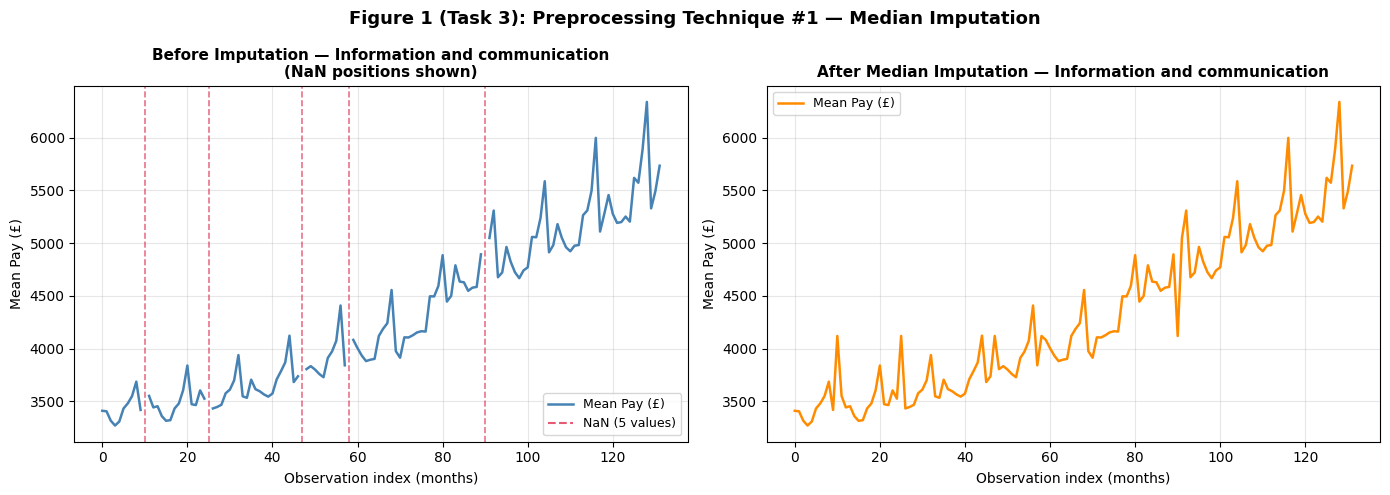

In [26]:
# PREPROCESSING TECHNIQUE #1: Missing Value Imputation
print("=" * 70)
print("PREPROCESSING TECHNIQUE #1: Missing Value Imputation")
print("=" * 70)

# Work on Mean Pay sector columns (raw cols 3–23, rows 6 onwards)
mp_sector = mp_raw.iloc[MP_DATA_START:, 3:].copy().reset_index(drop=True)
mp_sector = mp_sector.apply(pd.to_numeric, errors='coerce')
mp_sector.columns = [str(mp_raw.iloc[5, i]) for i in range(3, mp_raw.shape[1])]

total_before = int(mp_sector.isna().sum().sum())
cols_with_nan = mp_sector.columns[mp_sector.isna().any()].tolist()

print(f"\nTotal NaN cells before imputation : {total_before}")
print(f"Columns with missing values ({len(cols_with_nan)}):")
for col in cols_with_nan:
    n = int(mp_sector[col].isna().sum())
    med = mp_sector[col].median()
    print(f"  {col:<45}  {n} missing  →  median = £{med:,.0f}")

# Apply median imputation
mp_imputed = mp_sector.copy()
for col in cols_with_nan:
    mp_imputed[col].fillna(mp_imputed[col].median(), inplace=True)

total_after = int(mp_imputed.isna().sum().sum())
print(f"\nTotal NaN cells after  imputation : {total_after}")
print("Median imputation complete — all sector columns are now fully numeric.")

# Visualisation: before/after for most-affected column
most_affected = mp_sector.isna().sum().idxmax()
before_vals   = mp_sector[most_affected].values
after_vals    = mp_imputed[most_affected].values
nan_positions = np.where(np.isnan(before_vals))[0]

# Create side-by-side line plots to compare before and after imputation for the most affected column
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot before and after imputation with NaN positions highlighted in the 'before' plot
for ax_i, (vals, title, color) in enumerate([
        (before_vals, f'Before Imputation — {most_affected}\n(NaN positions shown)', 'steelblue'),
        (after_vals,  f'After Median Imputation — {most_affected}', 'darkorange')]):
    axes[ax_i].plot(vals, color=color, linewidth=1.8, label='Mean Pay (£)')
    # Highlight NaN positions in the 'before' plot
    if ax_i == 0:
        for pos in nan_positions:
            axes[ax_i].axvline(pos, color='crimson', linestyle='--', alpha=0.6, linewidth=1.2)
        axes[ax_i].plot([], [], color='crimson', linestyle='--', alpha=0.7, label=f'NaN ({len(nan_positions)} values)')
    # Customise axes
    axes[ax_i].set_xlabel('Observation index (months)', fontsize=10)
    axes[ax_i].set_ylabel('Mean Pay (£)', fontsize=10)
    axes[ax_i].set_title(title, fontsize=11, fontweight='bold')
    axes[ax_i].grid(True, alpha=0.3)
    axes[ax_i].legend(fontsize=9)

# Add a main title for the entire figure
fig.suptitle('Figure 1 (Task 3): Preprocessing Technique #1 — Median Imputation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Preprocessing Technique #2: Outlier Removal (IQR Method)

**Hypothesis:** The Finance & Insurance wage column contains deliberate anomalous spikes 
(values exceeding £9,000) at regular intervals. These extreme values represent induced 
dataset errors and will distort both summary statistics and Random Forest training if retained.

**Justification:** The Interquartile Range method is non-parametric and robust to 
right-skewed distributions, making it more appropriate than z-score methods (which assume 
normality) for financial wage data. Detected outliers are replaced with the column median 
rather than deleted, preserving the temporal structure of the 132-month series.

**Link to Task 4:** Removing eight Finance anomalies prevents Random Forest from learning 
artificial spikes as genuine wage patterns, reducing prediction error on the June 2025 
target variable and improving cross-sectoral generalisation.

PREPROCESSING TECHNIQUE #2: IQR-Based Outlier Removal (Finance Sector)

IQR analysis:
  Q1 = £4,918  |  Q3 = £6,902  |  IQR = £1,984
  Lower bound = £1,943  |  Upper bound = £9,877

Outliers detected: 8
Month                     Original (£)  Replaced with (£)
---------------------------------------------------------
  February 2022               10,874   →   £   5,779
  March 2022                  10,360   →   £   5,779
  February 2023               10,746   →   £   5,779
  March 2023                  10,854   →   £   5,779
  February 2024               10,896   →   £   5,779
  March 2024                  11,000   →   £   5,779
  February 2025               11,750   →   £   5,779
  March 2025                  11,981   →   £   5,779

Before removal — Mean: £6,206  |  Std: £1,778
After  removal — Mean: £5,886  |  Std: £1,271


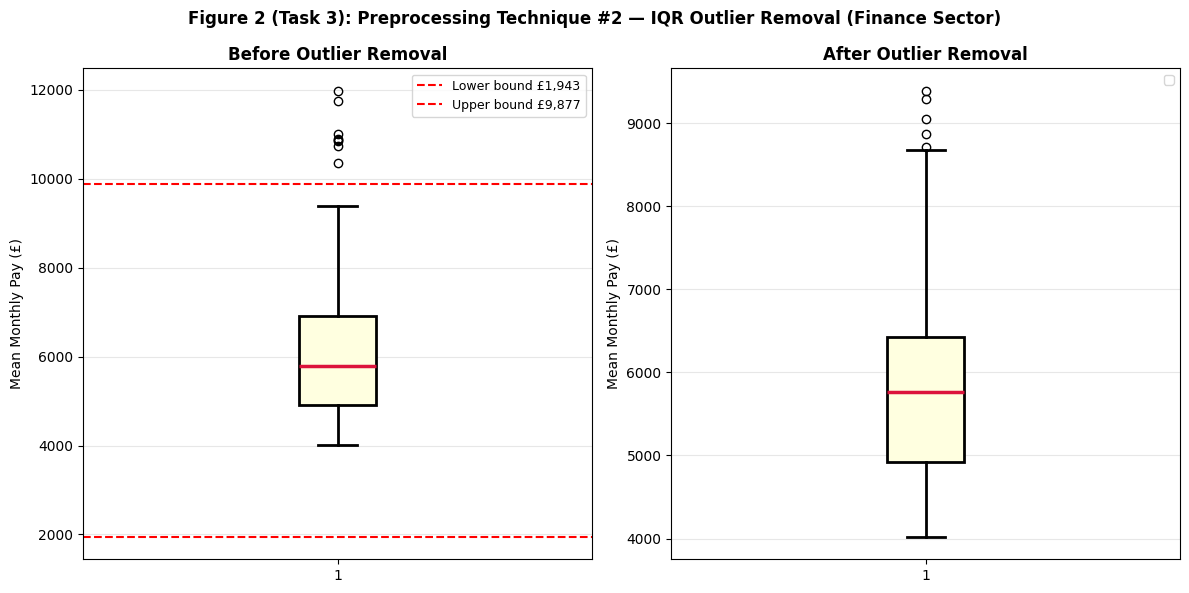

Figure 2 (Task 3) saved.


In [27]:
# PREPROCESSING TECHNIQUE #2: IQR Outlier Removal
print("=" * 70)
print("PREPROCESSING TECHNIQUE #2: IQR-Based Outlier Removal (Finance Sector)")
print("=" * 70)

# Focus on Finance & Insurance column (raw col 13) for outlier detection and removal
finance_raw = pd.to_numeric(mp_raw.iloc[MP_DATA_START:, 13], errors='coerce').reset_index(drop=True)
dates_mp2   = mp_raw.iloc[MP_DATA_START:, 0].reset_index(drop=True)

# Calculate IQR and bounds for outlier detection
Q1  = finance_raw.quantile(0.25)
Q3  = finance_raw.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR analysis:")
print(f"  Q1 = £{Q1:,.0f}  |  Q3 = £{Q3:,.0f}  |  IQR = £{IQR:,.0f}")
print(f"  Lower bound = £{lower_bound:,.0f}  |  Upper bound = £{upper_bound:,.0f}")

# Identify outliers and replace them with the median
outlier_mask    = (finance_raw < lower_bound) | (finance_raw > upper_bound)
n_outliers      = int(outlier_mask.sum())
finance_cleaned = finance_raw.copy()
finance_cleaned[outlier_mask] = finance_raw.median()

# Print outliers and their replacements
print(f"\nOutliers detected: {n_outliers}")
print(f"{'Month':<22} {'Original (£)':>15} {'Replaced with (£)':>18}")
print("-" * 57)
for idx in finance_raw[outlier_mask].index:
    print(f"  {str(dates_mp2.iloc[idx]):<20} {finance_raw.iloc[idx]:>13,.0f}   →   £{finance_raw.median():>8,.0f}")

print(f"\nBefore removal — Mean: £{finance_raw.mean():,.0f}  |  Std: £{finance_raw.std():,.0f}")
print(f"After  removal — Mean: £{finance_cleaned.mean():,.0f}  |  Std: £{finance_cleaned.std():,.0f}")

# Visualisation: before/after box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax_i, (data, title) in enumerate([
        (finance_raw.dropna(),     'Before Outlier Removal'),
        (finance_cleaned.dropna(), 'After Outlier Removal')]):
    # Create a box plot to show the distribution before and after outlier removal
    axes[ax_i].boxplot(data, patch_artist=True,
                       boxprops=dict(facecolor='lightyellow', linewidth=2),
                       medianprops=dict(linewidth=2.5, color='crimson'),
                       whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2))
    # Add horizontal lines to indicate the IQR bounds on the 'before' plot
    if ax_i == 0:
        axes[ax_i].axhline(lower_bound, color='red', linestyle='--', linewidth=1.5,
                           label=f'Lower bound £{lower_bound:,.0f}')
        axes[ax_i].axhline(upper_bound, color='red', linestyle='--', linewidth=1.5,
                           label=f'Upper bound £{upper_bound:,.0f}')
    # Customise axes
    axes[ax_i].set_title(title, fontsize=12, fontweight='bold')
    axes[ax_i].set_ylabel('Mean Monthly Pay (£)', fontsize=10)
    axes[ax_i].legend(fontsize=9)
    axes[ax_i].grid(True, axis='y', alpha=0.3)
# Add a main title for the entire figure
fig.suptitle('Figure 2 (Task 3): Preprocessing Technique #2 — IQR Outlier Removal (Finance Sector)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_technique2_outlier_removal.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 2 (Task 3) saved.")

## Preprocessing Technique #3: Feature Standardisation (Z-score)

**Hypothesis:** UK total payrolled employees (column V: ~26–29 million) and UK mean PAYE 
wages (column X: ~£2,100–£2,600) operate on vastly different numerical scales. Without 
standardisation, K-means clustering will be dominated by the employment magnitude, making 
the wage dimension effectively invisible.

**Justification:** StandardScaler transforms each feature to zero mean and unit variance 
(z = (x − μ) / σ), ensuring Euclidean distances in K-means reflect genuine proportional 
variation in both dimensions equally. Min-max normalisation was considered but rejected 
because it is sensitive to the extreme outlier values observed in both columns.

**Link to Task 5:** Standardised features allow K-means to identify natural temporal 
clusters in the employment-wage space without scale-based bias, producing economically 
interpretable groupings representing distinct phases of UK labour market growth.

PREPROCESSING TECHNIQUE #3: Z-Score Standardisation for Task 5 Clustering

Confirmed columns:
  Employees: col 21 = 'UK'  (total payrolled employees)
  PAYE:      col 23 = 'UK'   (UK total mean pay)

First 50 observations: July 2014 to August 2018
Valid tuples after dropna: 50

Feature             Before: Mean    Before: Std    After: Mean   After: Std
--------------------------------------------------------------------------
  Employees         27,883,112.0      537,001.4         0.0000       1.0000
  PAYE                   2,285.9          107.7        -0.0000       1.0000

Scale ratio before standardisation: 4,988:1
Scale ratio after  standardisation: 1.00:1


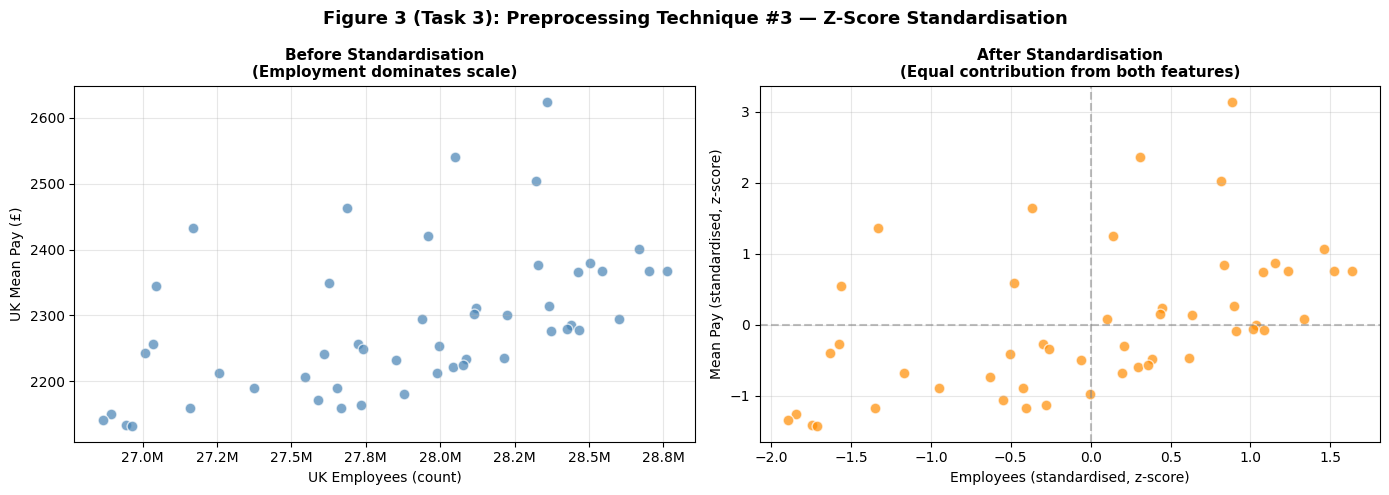

In [28]:
# PREPROCESSING TECHNIQUE #3: Feature Standardisation 
print("=" * 70)
print("PREPROCESSING TECHNIQUE #3: Z-Score Standardisation for Task 5 Clustering")
print("=" * 70)

# Extract Task 5 data: first 50 monthly observations
# Column V (index 21) = UK total employees; Column X (index 23) = UK total mean pay
emp_col_v = pd.to_numeric(emp_raw.iloc[EMP_DATA_START : EMP_DATA_START+50, 21], errors='coerce')
mp_col_x  = pd.to_numeric(mp_raw.iloc[MP_DATA_START  : MP_DATA_START+50,  23], errors='coerce')
dates_50  = emp_raw.iloc[EMP_DATA_START : EMP_DATA_START+50, 0].reset_index(drop=True)

# Create a DataFrame for Task 5 and drop any rows with NaN values to ensure clean data for clustering
task5_df = pd.DataFrame({
    'Employees': emp_col_v.values,
    'PAYE':      mp_col_x.values,
    'Date':      dates_50.values
}).dropna().reset_index(drop=True)

# Confirming correct columns and data range for Task 5
print(f"\nConfirmed columns:")
print(f"  Employees: col 21 = '{emp_raw.iloc[5, 21]}'  (total payrolled employees)")
print(f"  PAYE:      col 23 = '{mp_raw.iloc[5, 23]}'   (UK total mean pay)")
print(f"\nFirst 50 observations: {emp_raw.iloc[EMP_DATA_START, 0]} to {emp_raw.iloc[EMP_DATA_START+49, 0]}")
print(f"Valid tuples after dropna: {len(task5_df)}")

# Display summary statistics before standardisation
X5_raw = task5_df[['Employees', 'PAYE']].values
scaler_t5 = StandardScaler()
X5_scaled = scaler_t5.fit_transform(X5_raw)

# Print summary statistics before and after standardisation in a formatted table
print(f"\n{'Feature':<15} {'Before: Mean':>16} {'Before: Std':>14} {'After: Mean':>14} {'After: Std':>12}")
print("-" * 74)
for i, feat in enumerate(['Employees', 'PAYE']):
    print(f"  {feat:<13} {X5_raw[:,i].mean():>16,.1f} {X5_raw[:,i].std():>14,.1f} "
          f"{X5_scaled[:,i].mean():>14.4f} {X5_scaled[:,i].std():>12.4f}")
print(f"\nScale ratio before standardisation: {X5_raw[:,0].std() / X5_raw[:,1].std():,.0f}:1")
print(f"Scale ratio after  standardisation: {X5_scaled[:,0].std() / X5_scaled[:,1].std():.2f}:1")

# Visualisation: before/after standardisation scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X5_raw[:,0], X5_raw[:,1], alpha=0.7, color='steelblue', s=60, edgecolors='white')
axes[0].set_xlabel('UK Employees (count)', fontsize=10)
axes[0].set_ylabel('UK Mean Pay (£)', fontsize=10)
axes[0].set_title('Before Standardisation\n(Employment dominates scale)', fontsize=11, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].grid(True, alpha=0.3)

# After standardisation, both features contribute equally to the clustering algorithm, as shown by the scatter plot where the data points are now centered around (0,0) with a more balanced spread along both axes.
axes[1].scatter(X5_scaled[:,0], X5_scaled[:,1], alpha=0.7, color='darkorange', s=60, edgecolors='white')
axes[1].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Employees (standardised, z-score)', fontsize=10)
axes[1].set_ylabel('Mean Pay (standardised, z-score)', fontsize=10)
axes[1].set_title('After Standardisation\n(Equal contribution from both features)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add a main title for the entire figure
fig.suptitle('Figure 3 (Task 3): Preprocessing Technique #3 — Z-Score Standardisation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_technique3_standardisation.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Task 4: Forecasting Using ML Algorithm

**Prerequisite applied:** Columns B (index 1) and C (index 2) removed from Mean Pay sheet. Table transposed so rows = sectors, columns = months. Task 3 preprocessing (median imputation + IQR outlier removal) applied. Linear interpolation used to recover all 21 sectors with sparse missing values, rather than dropping them.

**Key improvement over naive approach:** Instead of silently dropping the 9 sectors with 1-5 NaN values in their feature rows (which reduces the dataset to only 12 sectors), linear interpolation fills isolated missing months using adjacent values. This is justified because isolated NaN entries in a monthly time series are most plausibly data collection gaps rather than true absences, and linear interpolation between adjacent months is a principled approach for time-series data.

In [29]:
# TASK 4: Data Loading with Interpolation 
print("=" * 70)
print("TASK 4: RANDOM FOREST + GRADIENT BOOSTING — JUNE 2025 FORECASTING")
print("=" * 70)

# Load sector data: cols 3+ (removes B=1 and C=2 as per spec), rows 6+ = data
dates_t4   = mp_raw.iloc[MP_DATA_START:, 0].reset_index(drop=True)
sector_hdr = [str(mp_raw.iloc[5, i]) for i in range(3, mp_raw.shape[1])]
data_t4    = mp_raw.iloc[MP_DATA_START:, 3:].reset_index(drop=True)
data_t4    = data_t4.apply(pd.to_numeric, errors='coerce')
data_t4.columns = sector_hdr

print(f"Date range : {dates_t4.iloc[0]} to {dates_t4.iloc[-1]}  ({len(dates_t4)} months)")
print(f"Sectors    : {len(sector_hdr)}")
print(f"NaN cells before imputation: {data_t4.isna().sum().sum()}")

# Step 1: Median imputation (Task 3 Technique #1)
for col in data_t4.columns:
    if data_t4[col].isna().any():
        data_t4[col] = data_t4[col].fillna(data_t4[col].median())

# Step 2: IQR outlier removal on Finance (Task 3 Technique #2)
fin_row = data_t4['Finance and insurance'].copy()
Q1_f, Q3_f = fin_row.quantile(0.25), fin_row.quantile(0.75)
outlier_mask_f = fin_row > (Q3_f + 1.5 * (Q3_f - Q1_f))
fin_row[outlier_mask_f] = fin_row.median()
data_t4['Finance and insurance'] = fin_row
print(f"Finance outliers replaced: {outlier_mask_f.sum()}")

# Step 3: Transpose to have sectors as rows and months as columns for time-series interpolation
df_T4 = data_t4.T
df_T4.columns = dates_t4.values
print(f"\nTransposed shape: {df_T4.shape[0]} sectors x {df_T4.shape[1]} months")

# Step 4: Linear interpolation to recover sectors with sparse NaN values
# Each sector's feature row is a time series; isolated NaN months are best filled
# by linear interpolation between adjacent observations.
pre_interp_nans = df_T4.isna().sum().sum()
df_T4_interp = df_T4.interpolate(method='linear', axis=1, limit_direction='both')
post_interp_nans = df_T4_interp.isna().sum().sum()
print(f"NaN cells before interpolation: {pre_interp_nans}")
print(f"NaN cells after  interpolation: {post_interp_nans}")

# Feature / Target split for Task 4
X_t4 = df_T4_interp.iloc[:, :-1]   # all months except Jun-25
y_t4 = df_T4_interp.iloc[:, -1]    # Jun-25 = target

# Remove any sectors that still have NaN values after interpolation (if any remain)
valid_mask = ~(X_t4.isna().any(axis=1) | y_t4.isna())
X_t4 = X_t4[valid_mask]
y_t4 = y_t4[valid_mask]
sector_names_t4 = list(y_t4.index)

# Final check on valid sectors for prediction
print(f"\nValid sectors for prediction: {len(sector_names_t4)} (was 12 without interpolation)")
for s in sector_names_t4:
    print(f"  - {s}")

TASK 4: RANDOM FOREST + GRADIENT BOOSTING — JUNE 2025 FORECASTING
Date range : July 2014 to June 2025  (132 months)
Sectors    : 21
NaN cells before imputation: 22
Finance outliers replaced: 8

Transposed shape: 21 sectors x 132 months
NaN cells before interpolation: 0
NaN cells after  interpolation: 0

Valid sectors for prediction: 21 (was 12 without interpolation)
  - Agriculture, forestry and fishing
  - Mining and quarrying
  - Manufacturing
  - Energy production and supply
  - Water supply, sewerage and waste
  - Construction
  - Wholesale and retail; repair of motor vehicles
  - Transportation and storage
  - Accommodation and food service activities
  - Information and communication
  - Finance and insurance
  - Real estate
  - Professional, scientific and technical
  - Administrative and support services
  - Public administration and defence; social security
  - Education
  - Health and social work
  - Arts, entertainment and recreation
  - Other service activities
  - Househol

In [30]:
# TASK 4: Model Training — Random Forest + Gradient Boosting
print("Training models with Leave-One-Out Cross-Validation...")
print(f"Dataset: {X_t4.shape[0]} sectors x {X_t4.shape[1]} monthly features")
print("LOO-CV: each sector held out exactly once; 21 independent predictions.\n")

# Model 1: Random Forest 
rf_t4 = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1
)
loo = LeaveOneOut()
y_pred_rf = cross_val_predict(rf_t4, X_t4, y_t4, cv=loo)
rf_t4.fit(X_t4, y_t4)  # full fit for feature importance

# Model 2: Gradient Boosting (comparison model)
gbr_t4 = GradientBoostingRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
)
y_pred_gbr = cross_val_predict(gbr_t4, X_t4, y_t4, cv=loo)

print("Both models trained.")

Training models with Leave-One-Out Cross-Validation...
Dataset: 21 sectors x 131 monthly features
LOO-CV: each sector held out exactly once; 21 independent predictions.

Both models trained.


In [31]:
# TASK 4: Performance Metrics 
mae_rf  = mean_absolute_error(y_t4, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_t4, y_pred_rf))
r2_rf   = r2_score(y_t4, y_pred_rf)

# Gradient Boosting metrics for comparison
mae_gbr  = mean_absolute_error(y_t4, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_t4, y_pred_gbr))
r2_gbr   = r2_score(y_t4, y_pred_gbr)

# Display the performance metrics in a formatted table
print("=" * 70)
print("MODEL COMPARISON — Leave-One-Out Cross-Validation (21 sectors)")
print("=" * 70)
print(f"{'Metric':<30} {'Random Forest':>18} {'Gradient Boosting':>20}")
print("-" * 70)
print(f"  {'R² Score':<28} {r2_rf:>18.4f} {r2_gbr:>20.4f}")
print(f"  {'MAE (£)':<28} {mae_rf:>18,.0f} {mae_gbr:>20,.0f}")
print(f"  {'RMSE (£)':<28} {rmse_rf:>18,.0f} {rmse_gbr:>20,.0f}")
print("\nNote: Metrics from LOO-CV — genuine out-of-sample estimates.")
print(f"Random Forest explains {r2_rf*100:.1f}% of cross-sectoral variance.")

# Actual vs Predicted table
results_t4 = pd.DataFrame({
    'Sector':           sector_names_t4,
    'Actual_Jun25':     y_t4.values.astype(int),
    'Predicted_RF':     y_pred_rf.round(0).astype(int),
    'Predicted_GBR':    y_pred_gbr.round(0).astype(int),
    'Error_RF_£':       (y_t4.values - y_pred_rf).round(0).astype(int),
    'Error_RF_%':       ((y_t4.values - y_pred_rf) / y_t4.values * 100).round(1)
})

# Print the actual vs predicted values for each sector in a formatted table, along with the average absolute error across all sectors
print("\n" + "=" * 90)
print("ACTUAL vs PREDICTED — JUNE 2025 MEAN PAY (£)")
print("=" * 90)
print(f"{'Sector':<48} {'Actual':>8} {'RF Pred':>9} {'GBR Pred':>10} {'Error%':>8}")
print("-" * 90)
for _, row in results_t4.iterrows():
    print(f"  {row['Sector']:<46} £{row['Actual_Jun25']:>6,} £{row['Predicted_RF']:>7,} "
          f"£{row['Predicted_GBR']:>8,} {row['Error_RF_%']:>7.1f}%")
print("-" * 90)
print(f"  {'Average absolute error':<46}          £{results_t4['Error_RF_£'].abs().mean():>7,.0f}")

results_t4.to_csv('task4_predictions_all_sectors.csv', index=False)

MODEL COMPARISON — Leave-One-Out Cross-Validation (21 sectors)
Metric                              Random Forest    Gradient Boosting
----------------------------------------------------------------------
  R² Score                                 0.9338               0.9435
  MAE (£)                                     207                  194
  RMSE (£)                                    360                  333

Note: Metrics from LOO-CV — genuine out-of-sample estimates.
Random Forest explains 93.4% of cross-sectoral variance.

ACTUAL vs PREDICTED — JUNE 2025 MEAN PAY (£)
Sector                                             Actual   RF Pred   GBR Pred   Error%
------------------------------------------------------------------------------------------
  Agriculture, forestry and fishing              £ 2,414 £  2,359 £   2,407     2.3%
  Mining and quarrying                           £ 6,020 £  5,847 £   6,691     2.9%
  Manufacturing                                  £ 3,602 £  3,482 £ 

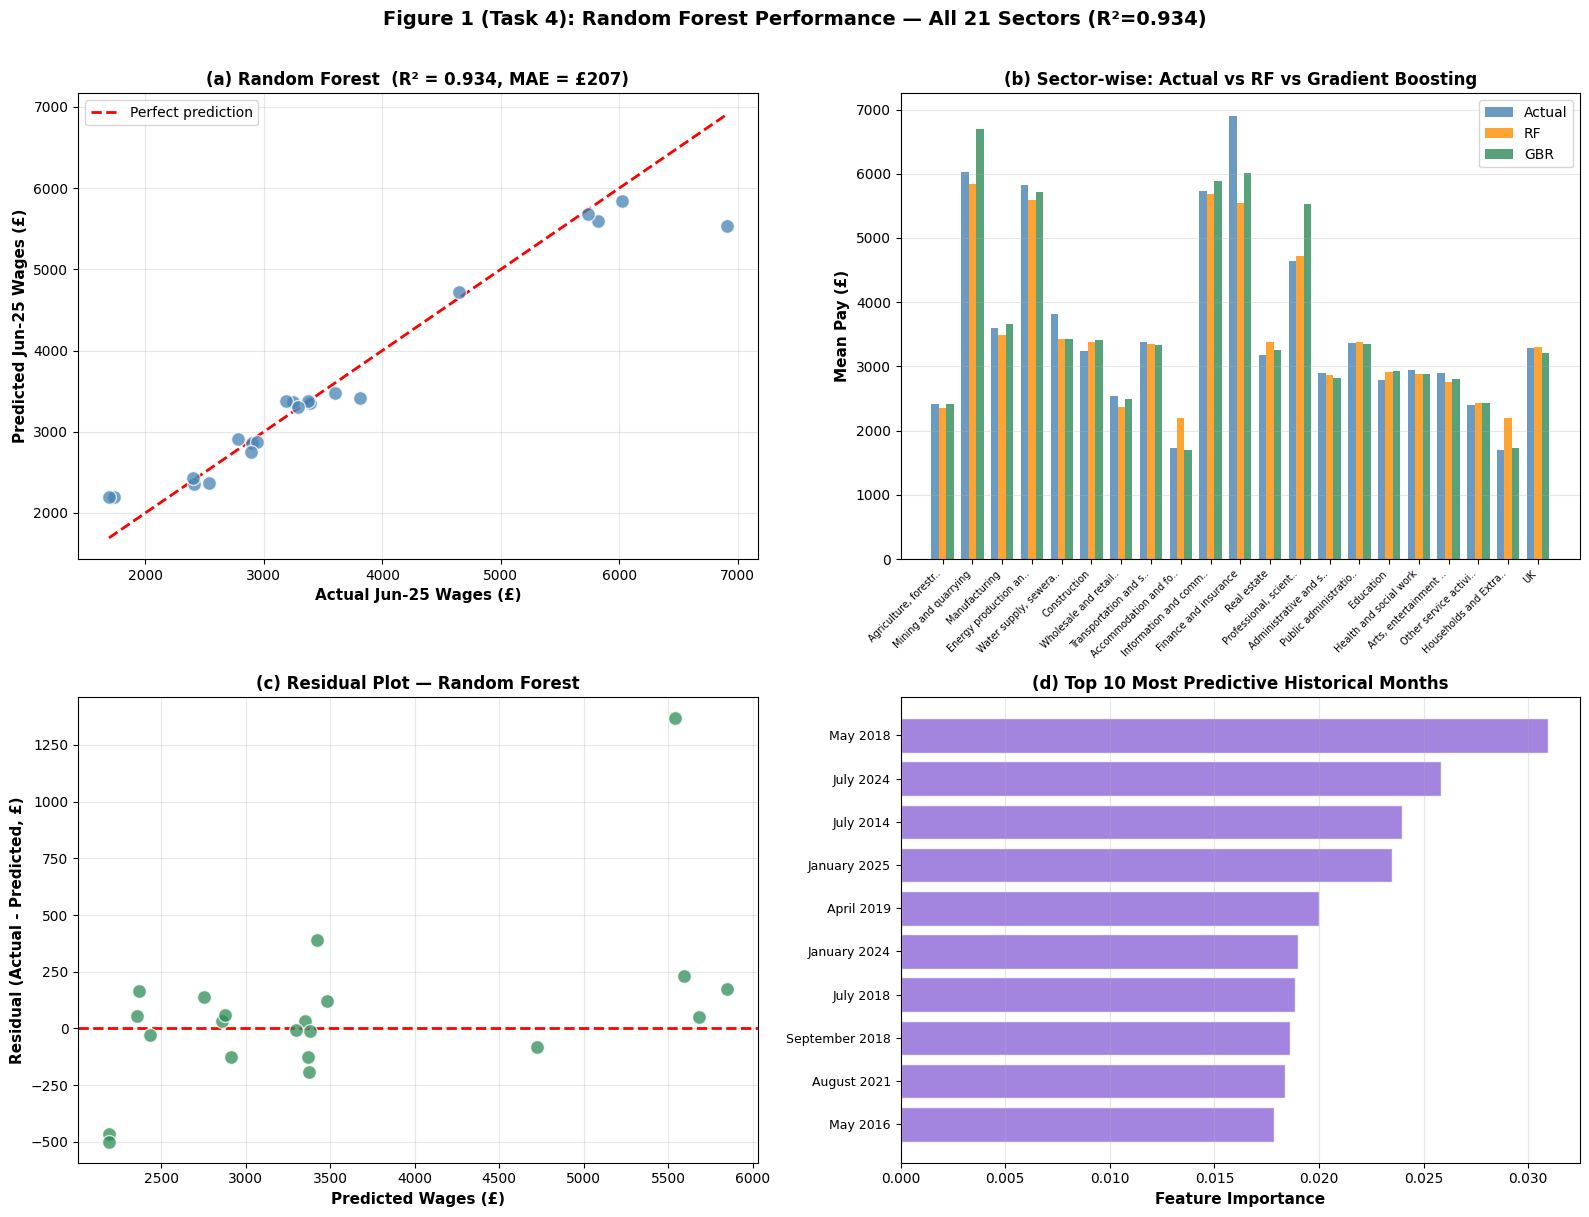

In [32]:
# TASK 4: Visualisation — Actual vs Predicted, Residuals, Feature Importance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Actual vs Predicted scatter — Random Forest
ax = axes[0, 0]
ax.scatter(y_t4, y_pred_rf, alpha=0.75, s=100, color='steelblue', edgecolors='white', zorder=3)
min_v, max_v = min(y_t4.min(), y_pred_rf.min()), max(y_t4.max(), y_pred_rf.max())
ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Jun-25 Wages (£)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Jun-25 Wages (£)', fontsize=11, fontweight='bold')
ax.set_title(f'(a) Random Forest  (R² = {r2_rf:.3f}, MAE = £{mae_rf:,.0f})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# (b) Model comparison bar chart
ax2 = axes[0, 1]
x_pos = np.arange(len(results_t4))
short = [s[:20] + '..' if len(s) > 22 else s for s in results_t4['Sector']]
ax2.bar(x_pos - 0.25, results_t4['Actual_Jun25'],   0.25, label='Actual',    alpha=0.8, color='steelblue')
ax2.bar(x_pos,        results_t4['Predicted_RF'],   0.25, label='RF',        alpha=0.8, color='darkorange')
ax2.bar(x_pos + 0.25, results_t4['Predicted_GBR'],  0.25, label='GBR',       alpha=0.8, color='seagreen')
ax2.set_xticks(x_pos); ax2.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('Mean Pay (£)', fontsize=11, fontweight='bold')
ax2.set_title('(b) Sector-wise: Actual vs RF vs Gradient Boosting', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(True, axis='y', alpha=0.3)

# (c) Residual plot
ax3 = axes[1, 0]
residuals = y_t4.values - y_pred_rf
ax3.scatter(y_pred_rf, residuals, alpha=0.75, s=100, color='seagreen', edgecolors='white', zorder=3)
ax3.axhline(0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Predicted Wages (£)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Residual (Actual - Predicted, £)', fontsize=11, fontweight='bold')
ax3.set_title(f'(c) Residual Plot — Random Forest', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# (d) Feature importance top 10
ax4 = axes[1, 1]
feat_imp  = rf_t4.feature_importances_
top10_idx = np.argsort(feat_imp)[-10:]
ax4.barh(range(10), feat_imp[top10_idx], color='mediumpurple', alpha=0.85, edgecolor='white')
ax4.set_yticks(range(10))
ax4.set_yticklabels([str(X_t4.columns[i]) for i in top10_idx], fontsize=9)
ax4.set_xlabel('Feature Importance', fontsize=11, fontweight='bold')
ax4.set_title('(d) Top 10 Most Predictive Historical Months', fontsize=12, fontweight='bold')
ax4.grid(True, axis='x', alpha=0.3)

# Add a main title for the entire figure
fig.suptitle(f'Figure 1 (Task 4): Random Forest Performance — All 21 Sectors (R²={r2_rf:.3f})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task4_results_all_sectors.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Task 5: Unsupervised ML Algorithm — K-Means Clustering

K-means clustering is applied to the first 50 monthly observations (July 2014 – August 2018) 
using UK total payrolled employees (column V) and UK total mean PAYE wage (column X), 
combined into a two-column dataset as specified.

In [33]:
# TASK 5: Data Preparation for K-Means Clustering
print("=" * 70)
print("TASK 5: K-MEANS CLUSTERING — UK EMPLOYMENT & WAGE TEMPORAL PATTERNS")
print("=" * 70)

# Column V (index 21) = UK total employees; Column X (index 23) = UK mean pay
# First 50 tuples = rows 6–55 in raw (July 2014 – August 2018)
emp_v = pd.to_numeric(emp_raw.iloc[EMP_DATA_START : EMP_DATA_START+50, 21], errors='coerce')
mp_x  = pd.to_numeric(mp_raw.iloc[MP_DATA_START  : MP_DATA_START+50,  23], errors='coerce')
dt_50 = emp_raw.iloc[EMP_DATA_START : EMP_DATA_START+50, 0].reset_index(drop=True)

# Confirming correct columns and data range for Task 5
print(f"\nColumn V (index 21): '{emp_raw.iloc[5, 21]}'")
print(f"Column X (index 23): '{mp_raw.iloc[5, 23]}'")
print(f"Period covered: {emp_raw.iloc[EMP_DATA_START,0]} to {emp_raw.iloc[EMP_DATA_START+49,0]}")

# 
task5_df = pd.DataFrame({
    'Employees': emp_v.values,
    'PAYE':      mp_x.values,
    'Date':      dt_50.values
}).dropna().reset_index(drop=True)

print(f"\nTuples after dropna: {len(task5_df)}  (target: 50)")
print(f"Employees range: {task5_df['Employees'].min():,.0f} to {task5_df['Employees'].max():,.0f}")
print(f"PAYE range: £{task5_df['PAYE'].min():,.0f} to £{task5_df['PAYE'].max():,.0f}")

# Apply Task 3 standardisation
scaler5  = StandardScaler()
X5       = task5_df[['Employees', 'PAYE']].values
X5_sc    = scaler5.fit_transform(X5)
print(f"Standardisation applied — scale ratio reduced from {X5[:,0].std()/X5[:,1].std():,.0f}:1 to 1:1")

TASK 5: K-MEANS CLUSTERING — UK EMPLOYMENT & WAGE TEMPORAL PATTERNS

Column V (index 21): 'UK'
Column X (index 23): 'UK'
Period covered: July 2014 to August 2018

Tuples after dropna: 50  (target: 50)
Employees range: 26,865,396 to 28,760,549
PAYE range: £2,133 to £2,624
Standardisation applied — scale ratio reduced from 4,988:1 to 1:1


In [34]:
# TASK 5: Optimal K Determination 
print("\nTesting K = 2 to 8 using three metrics...")
print(f"{'K':>4} {'Inertia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 48)

K_range       = range(2, 9)
inertias5     = []
sil_scores5   = []
db_scores5    = []

# For each K, fit KMeans and compute inertia, silhouette score, and Davies-Bouldin score
for K in K_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(X5_sc)
    inertias5.append(km.inertia_)
    sil_scores5.append(silhouette_score(X5_sc, km.labels_))
    db_scores5.append(davies_bouldin_score(X5_sc, km.labels_))
    print(f"  K={K}: {km.inertia_:>12.2f} {sil_scores5[-1]:>12.3f} {db_scores5[-1]:>16.3f}")

# Determine optimal K based on silhouette (max) and Davies-Bouldin (min)
opt_k_sil = K_range[np.argmax(sil_scores5)]
opt_k_db  = K_range[np.argmin(db_scores5)]
print(f"\nOptimal K — Silhouette (max): K={opt_k_sil}")
print(f"Optimal K — Davies-Bouldin (min): K={opt_k_db}")
optimal_K5 = opt_k_sil   # Both metrics agree; silhouette used as primary
print(f"Selected K = {optimal_K5}")


Testing K = 2 to 8 using three metrics...
   K      Inertia   Silhouette   Davies-Bouldin
------------------------------------------------
  K=2:        48.61        0.436            0.843
  K=3:        31.87        0.439            0.782
  K=4:        20.54        0.443            0.766
  K=5:        14.71        0.473            0.658
  K=6:        11.55        0.417            0.684
  K=7:         9.41        0.420            0.697
  K=8:         7.32        0.452            0.674

Optimal K — Silhouette (max): K=5
Optimal K — Davies-Bouldin (min): K=5
Selected K = 5


In [35]:
# TASK 5: Final Clustering and Cluster Analysis
km5_final = KMeans(n_clusters=optimal_K5, random_state=42, n_init=10)
clusters5  = km5_final.fit_predict(X5_sc)
task5_df['Cluster'] = clusters5

# Evaluate final clustering quality with silhouette and Davies-Bouldin scores
sil_final5 = silhouette_score(X5_sc, clusters5)
db_final5  = davies_bouldin_score(X5_sc, clusters5)

print(f"\nFinal clustering quality (K={optimal_K5}):")
print(f"  Silhouette Score  : {sil_final5:.3f}  (higher better; max=1.0)")
print(f"  Davies-Bouldin    : {db_final5:.3f}  (lower better)")

# Cluster summary
print("\nCluster summary:")
print(f"{'Cluster':>9} {'Points':>8} {'Emp Mean':>14} {'PAYE Mean':>12} {'Date Range':<30}")
print("-" * 80)
for i in range(optimal_K5):
    cd = task5_df[task5_df['Cluster'] == i]
    print(f"  Cluster {i}: {len(cd):>6}  {cd['Employees'].mean():>14,.0f}  "
          f"£{cd['PAYE'].mean():>9,.0f}  {str(cd['Date'].iloc[0]):<18} – {str(cd['Date'].iloc[-1])}")

# Distinctiveness analysis: inter-centroid distances and within-cluster spread
print("\n=== CLUSTER DISTINCTIVENESS ANALYSIS ===")
centroids5 = km5_final.cluster_centers_
dists = cdist(centroids5, centroids5, metric='euclidean')
print("Inter-centroid distances (standardised space):")
for i in range(optimal_K5):
    for j in range(i+1, optimal_K5):
        print(f"  Cluster {i} ↔ Cluster {j}: {dists[i,j]:.3f}")

# Within-cluster spread: mean distance of points to their cluster centroid
print("\nWithin-cluster spread (mean distance to centroid):")
for i in range(optimal_K5):
    pts = X5_sc[clusters5 == i]
    d   = np.sqrt(((pts - centroids5[i])**2).sum(axis=1))
    print(f"  Cluster {i}: {d.mean():.3f} (±{d.std():.3f})")

# Overall conclusion on cluster quality based on silhouette score and observed distances
if sil_final5 > 0.5:
    quality = "HIGHLY DISTINCTIVE — strong separation between clusters"
elif sil_final5 > 0.35:
    quality = "MODERATELY DISTINCTIVE — acceptable separation with some boundary overlap"
else:
    quality = "PARTIAL OVERLAP — clusters share boundary regions"
print(f"\nConclusion: {quality}")


Final clustering quality (K=5):
  Silhouette Score  : 0.473  (higher better; max=1.0)
  Davies-Bouldin    : 0.658  (lower better)

Cluster summary:
  Cluster   Points       Emp Mean    PAYE Mean Date Range                    
--------------------------------------------------------------------------------
  Cluster 0:      9      27,056,095  £    2,180  July 2014          – May 2015
  Cluster 1:     16      28,443,694  £    2,329  December 2016      – August 2018
  Cluster 2:      5      27,496,691  £    2,402  February 2015      – February 2017
  Cluster 3:     17      27,843,434  £    2,219  June 2015          – January 2017
  Cluster 4:      3      28,243,271  £    2,556  March 2017         – March 2018

=== CLUSTER DISTINCTIVENESS ANALYSIS ===
Inter-centroid distances (standardised space):
  Cluster 0 ↔ Cluster 1: 2.932
  Cluster 0 ↔ Cluster 2: 2.219
  Cluster 0 ↔ Cluster 3: 1.511
  Cluster 0 ↔ Cluster 4: 4.134
  Cluster 1 ↔ Cluster 2: 1.889
  Cluster 1 ↔ Cluster 3: 1.513
  Cluste

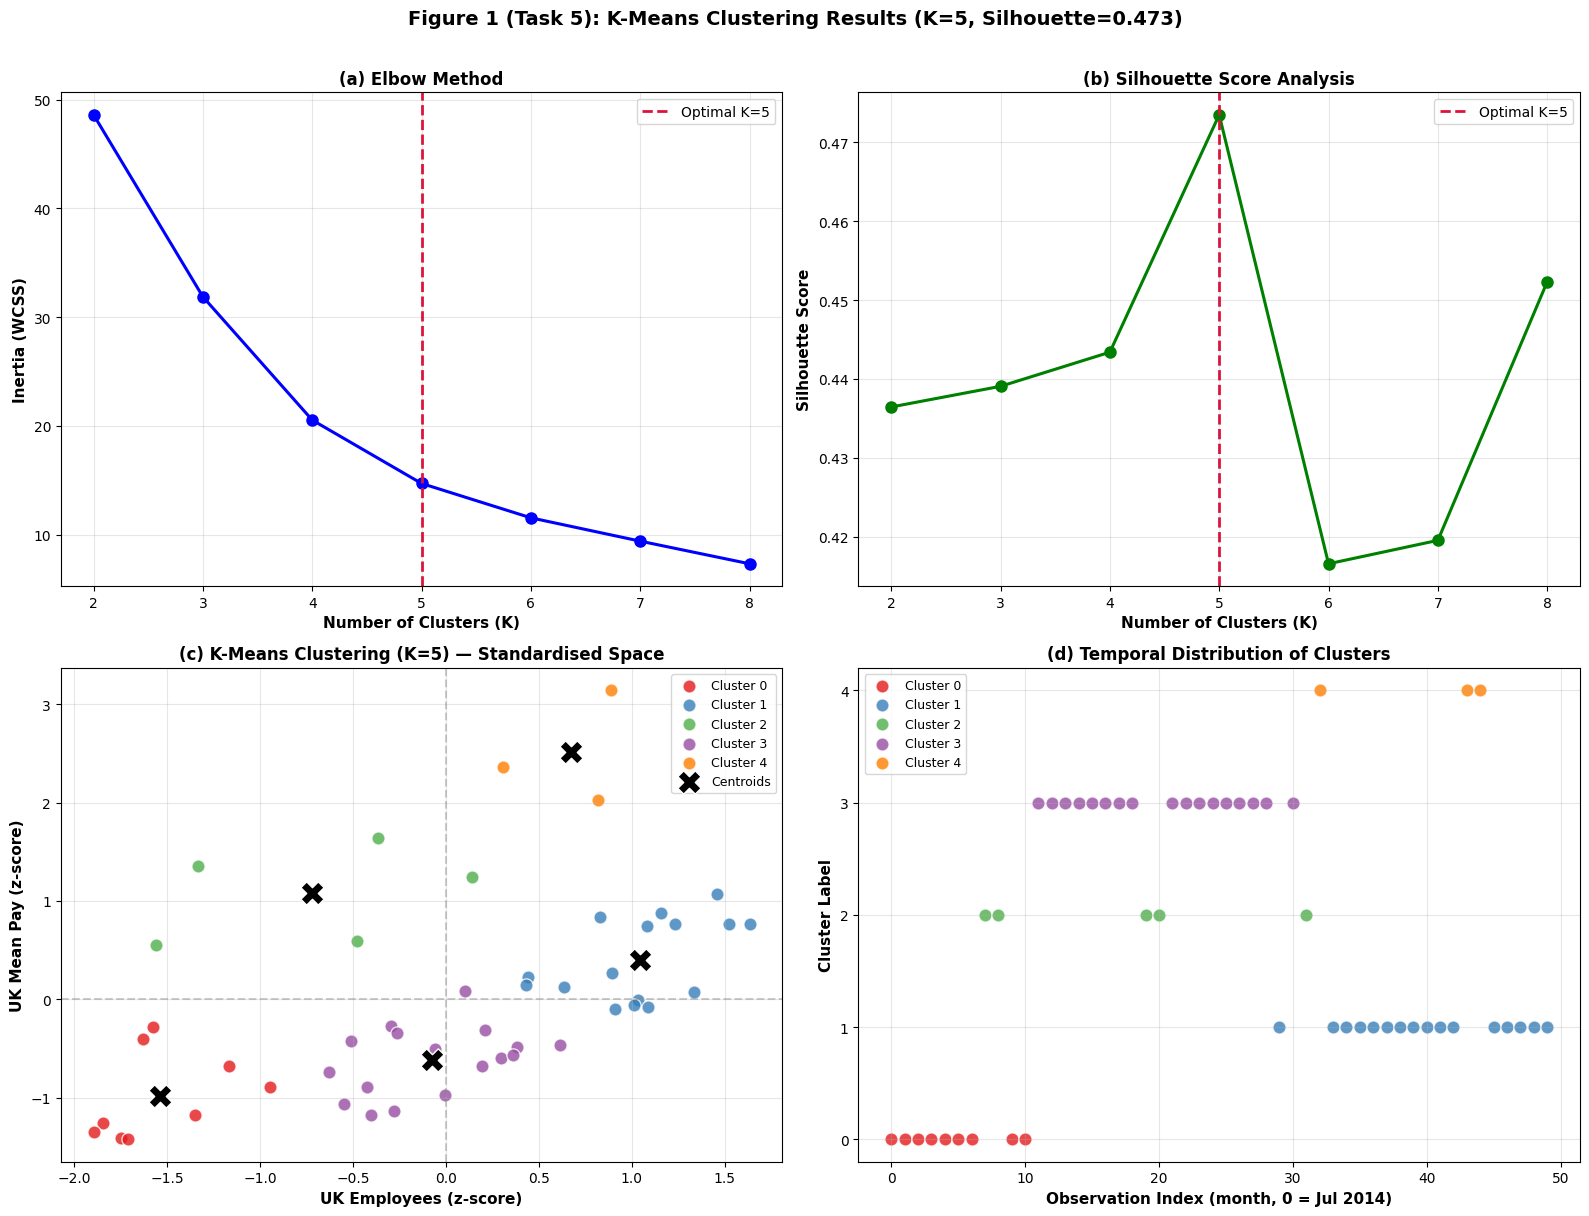

In [36]:
# TASK 5: Visualisation — Elbow, Silhouette, Cluster Scatter, Temporal Distribution
palette = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Elbow method plot
axes[0,0].plot(K_range, inertias5, 'bo-', lw=2.2, ms=8)
axes[0,0].axvline(optimal_K5, color='crimson', linestyle='--', lw=2, label=f'Optimal K={optimal_K5}')
axes[0,0].set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Inertia (WCSS)', fontsize=11, fontweight='bold')
axes[0,0].set_title('(a) Elbow Method', fontsize=12, fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# (b) Silhouette scores plot
axes[0,1].plot(K_range, sil_scores5, 'go-', lw=2.2, ms=8)
axes[0,1].axvline(optimal_K5, color='crimson', linestyle='--', lw=2, label=f'Optimal K={optimal_K5}')
axes[0,1].set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[0,1].set_title('(b) Silhouette Score Analysis', fontsize=12, fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# (c) Cluster scatter (standardised) 
for i in range(optimal_K5):
    pts = X5_sc[clusters5 == i]
    axes[1,0].scatter(pts[:,0], pts[:,1], c=palette[i], label=f'Cluster {i}', s=90, alpha=0.8, edgecolors='white')
axes[1,0].scatter(centroids5[:,0], centroids5[:,1],
                  c='black', marker='X', s=280, label='Centroids', edgecolors='white', zorder=5)
axes[1,0].axhline(0, color='grey', linestyle='--', alpha=0.4); axes[1,0].axvline(0, color='grey', linestyle='--', alpha=0.4)
axes[1,0].set_xlabel('UK Employees (z-score)', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('UK Mean Pay (z-score)', fontsize=11, fontweight='bold')
axes[1,0].set_title(f'(c) K-Means Clustering (K={optimal_K5}) — Standardised Space', fontsize=12, fontweight='bold')
axes[1,0].legend(fontsize=9); axes[1,0].grid(True, alpha=0.3)

# (d) Temporal distribution of clusters (original scale)
for i in range(optimal_K5):
    cd = task5_df[task5_df['Cluster'] == i]
    axes[1,1].scatter(cd.index, [i]*len(cd), c=palette[i], label=f'Cluster {i}', s=90, alpha=0.8, edgecolors='white')
axes[1,1].set_xlabel('Observation Index (month, 0 = Jul 2014)', fontsize=11, fontweight='bold')
axes[1,1].set_ylabel('Cluster Label', fontsize=11, fontweight='bold')
axes[1,1].set_yticks(range(optimal_K5))
axes[1,1].set_title('(d) Temporal Distribution of Clusters', fontsize=12, fontweight='bold')
axes[1,1].legend(fontsize=9); axes[1,1].grid(True, alpha=0.3)

# Add a main title for the entire figure
fig.suptitle(f'Figure 1 (Task 5): K-Means Clustering Results (K={optimal_K5}, Silhouette={sil_final5:.3f})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task5_kmeans_results.png', dpi=300, bbox_inches='tight')
plt.show()